# Robbins Labels Data Struture Analysis

In [27]:
import matplotlib.pyplot as plt
import numpy as np

from LRO_data_class import LunarDataset

## Basic Structure

In [28]:
dataLabels = LunarDataset().labels
dataLabels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296796 entries, 0 to 1296795
Data columns (total 21 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   CRATER_ID               1296796 non-null  object 
 1   LAT_CIRC_IMG            1296796 non-null  float64
 2   LON_CIRC_IMG            1296796 non-null  float64
 3   LAT_ELLI_IMG            1296758 non-null  float64
 4   LON_ELLI_IMG            1296758 non-null  float64
 5   DIAM_CIRC_IMG           1296796 non-null  float64
 6   DIAM_CIRC_SD_IMG        1296796 non-null  float64
 7   DIAM_ELLI_MAJOR_IMG     1296758 non-null  float64
 8   DIAM_ELLI_MINOR_IMG     1296758 non-null  float64
 9   DIAM_ELLI_ECCEN_IMG     1296758 non-null  float64
 10  DIAM_ELLI_ELLIP_IMG     1296758 non-null  float64
 11  DIAM_ELLI_ANGLE_IMG     1296758 non-null  float64
 12  LAT_ELLI_SD_IMG         1296796 non-null  float64
 13  LON_ELLI_SD_IMG         1296796 non-null  float64
 14  DI

In [29]:
print('Shape: ', dataLabels.shape)
print('Duplicates: ', dataLabels.duplicated().sum())
print('Null values')
print(dataLabels.isna().sum())


Shape:  (1296796, 21)
Duplicates:  0
Null values
CRATER_ID                  0
LAT_CIRC_IMG               0
LON_CIRC_IMG               0
LAT_ELLI_IMG              38
LON_ELLI_IMG              38
DIAM_CIRC_IMG              0
DIAM_CIRC_SD_IMG           0
DIAM_ELLI_MAJOR_IMG       38
DIAM_ELLI_MINOR_IMG       38
DIAM_ELLI_ECCEN_IMG       38
DIAM_ELLI_ELLIP_IMG       38
DIAM_ELLI_ANGLE_IMG       38
LAT_ELLI_SD_IMG            0
LON_ELLI_SD_IMG            0
DIAM_ELLI_MAJOR_SD_IMG    38
DIAM_ELLI_MINOR_SD_IMG    38
DIAM_ELLI_ANGLE_SD_IMG    38
DIAM_ELLI_ECCEN_SD_IMG    38
DIAM_ELLI_ELLIP_SD_IMG    38
ARC_IMG                    0
PTS_RIM_IMG                0
dtype: int64


## Crater size distribution

### Elliptical Crater Columns

The Robbins catalogue fits an ellipse to each crater rim and records the following measurements:

| Column | Description | Example |
|--------|-------------|---------|
| `DIAM_ELLI_MAJOR_IMG` | Length of the longest axis | 10 km |
| `DIAM_ELLI_MINOR_IMG` | Length of the shortest axis | 8 km |
| `DIAM_ELLI_ELLIP_IMG` | Ellipticity = major/minor (1 = perfect circle, higher = more elliptical) | 10/8 = 1.25 → elliptical |
| `DIAM_ELLI_ECCEN_IMG` | Eccentricity — another stretch measure (0 = circle, 1 = flat line) | 0.6 |
| `DIAM_ELLI_ANGLE_IMG` | Orientation angle of the ellipse on the lunar surface | 45° |

A threshold of **1.2** is used to separate circular (≤ 1.2) from elliptical (> 1.2) craters, consistent with Bottke et al. (2000) and the lunar crater literature.

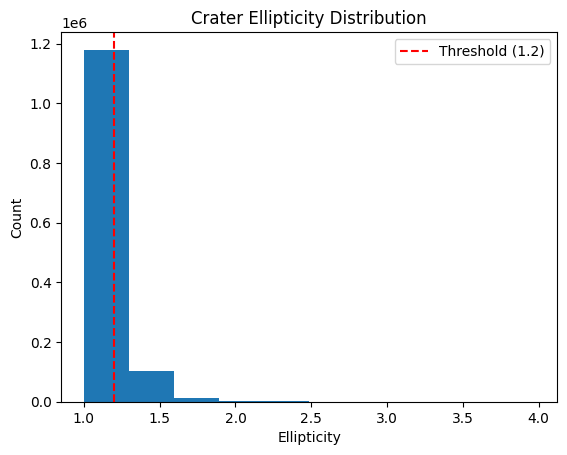

In [ ]:
# [source 1]: Robbins (2019) — https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2018JE005592

smallCraters = dataLabels['DIAM_CIRC_IMG'] < 10

plt.hist(dataLabels['DIAM_ELLI_ELLIP_IMG'])
plt.axvline(x=1.2, color='red', linestyle='--', label='Threshold (1.2)') # [1]

plt.xlabel('Ellipticity')
plt.ylabel('Count')
plt.title('Small Crater Ellipticity Distribution')
plt.legend()

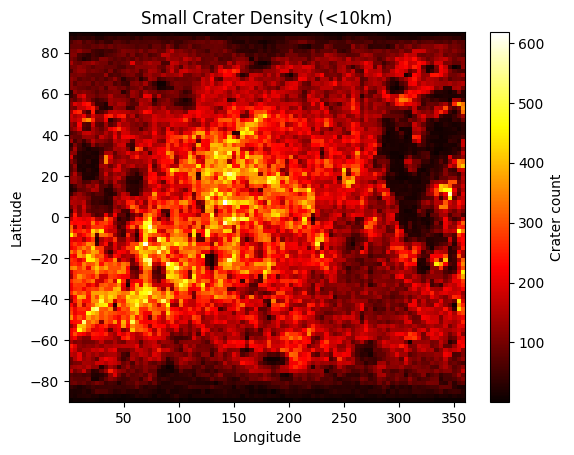

In [33]:
# plotting every small crater as a point on a map of the moon using its longitude and latitude
# bins=90 divides the moon into a 90x90 grid of cells

smallCraters = dataLabels[dataLabels['DIAM_CIRC_IMG'] < 10]

plt.hist2d(smallCraters['LON_CIRC_IMG'], smallCraters['LAT_CIRC_IMG'], bins=90, cmap='hot')
plt.colorbar(label='Crater count')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Small Crater Density (<10km)')
plt.show()